### L1 model training

Let's train a model using our baseline setup *with L1 regulization*. My network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats
from mlp.penalties import L1Penalty

In [2]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [3]:
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

error =  CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: 3.4s to complete
    error(train)=1.66e+00, acc(train)=5.58e-01, error(valid)=1.67e+00, acc(valid)=5.52e-01
Epoch 10: 3.5s to complete
    error(train)=1.23e+00, acc(train)=6.61e-01, error(valid)=1.23e+00, acc(valid)=6.56e-01
Epoch 20: 3.4s to complete
    error(train)=1.09e+00, acc(train)=6.90e-01, error(valid)=1.10e+00, acc(valid)=6.88e-01
Epoch 30: 3.1s to complete
    error(train)=1.02e+00, acc(train)=7.04e-01, error(valid)=1.03e+00, acc(valid)=7.00e-01
Epoch 40: 2.7s to complete
    error(train)=9.83e-01, acc(train)=7.14e-01, error(valid)=9.88e-01, acc(valid)=7.11e-01
Epoch 50: 2.5s to complete
    error(train)=9.55e-01, acc(train)=7.21e-01, error(valid)=9.60e-01, acc(valid)=7.17e-01
Epoch 60: 2.6s to complete
    error(train)=9.34e-01, acc(train)=7.27e-01, error(valid)=9.40e-01, acc(valid)=7.23e-01
Epoch 70: 2.5s to complete
    error(train)=9.17e-01, acc(train)=7.31e-01, error(valid)=9.24e-01, acc(valid)=7.28e-01
Epoch 80: 2.5s to complete
    error(train)=9.02e-01, acc

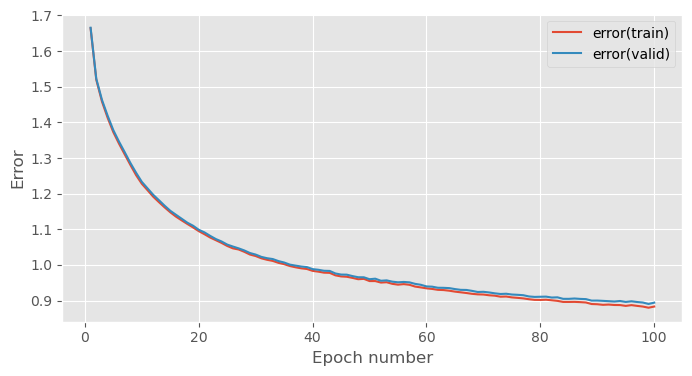

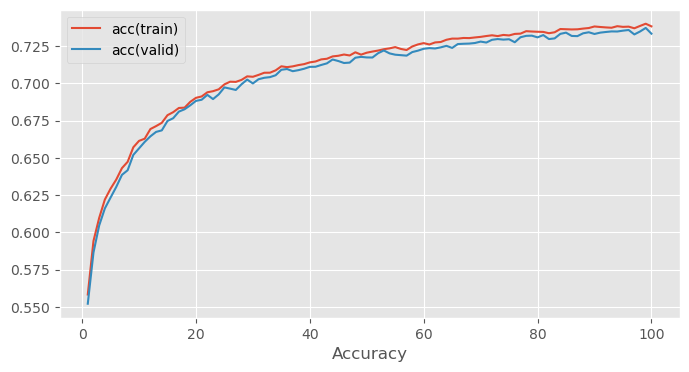

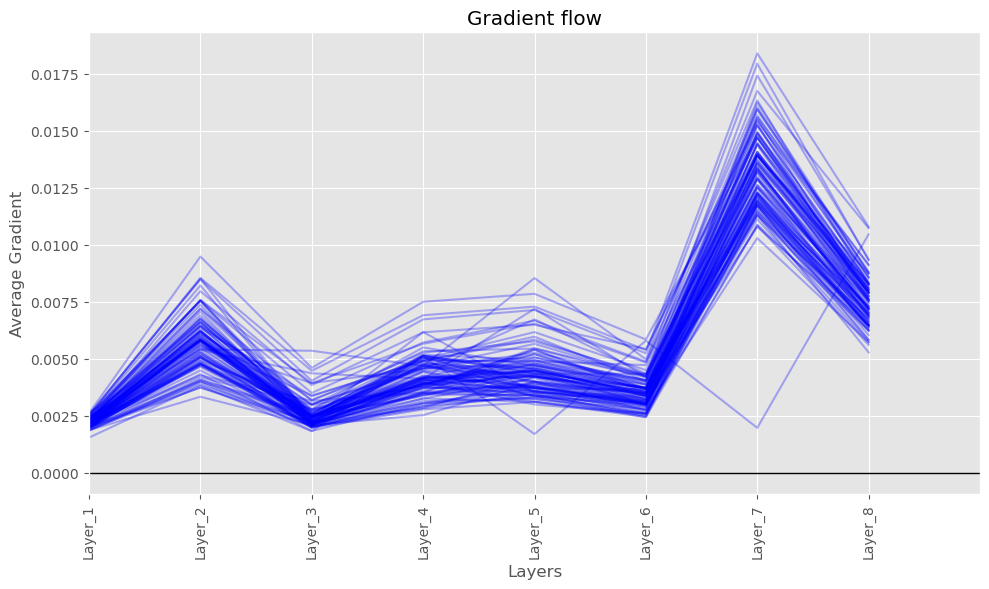

In [4]:
# Create model with three hidden layers and L1 penalties on weights and biases
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)) # output layer
])

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)